In [4]:
import scanpy as sc # specific to single cell RNA seq analysis ! 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import of all the libraries used afterwards. scanpy is essential 

In [20]:

import warnings
import logging

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


#sc.settings.verbosity = 1  # 0 = errors only, 1 = warnings, 2 = info, 3 = debug

logging.getLogger("scanpy").setLevel(logging.ERROR)
print(8)

8


some preferences about warnings and personnal infos  

In [21]:
adata = sc.datasets.pbmc3k()
print(adata)
print(adata.var_names[:10]) # ten first genes

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10'],
      dtype='object', name='index')


the data set PBMC 3k de 10X Genomics (2700 cells of peripheral blood) can be loaded directly from scanpy

In [22]:
print(adata.obs.head()) # see first cells 

print(adata.var.head()) # first genes 

print(f"Matrice : {adata.n_obs} cellules × {adata.n_vars} gènes") # matrix 

print(type(adata.X)) # type = sparse 

Empty DataFrame
Columns: []
Index: [AAACATACAACCAC-1, AAACATTGAGCTAC-1, AAACATTGATCAGC-1, AAACCGTGCTTCCG-1, AAACCGTGTATGCG-1]
                     gene_ids
index                        
MIR1302-10    ENSG00000243485
FAM138A       ENSG00000237613
OR4F5         ENSG00000186092
RP11-34P13.7  ENSG00000238009
RP11-34P13.8  ENSG00000239945
Matrice : 2700 cellules × 32738 gènes
<class 'scipy.sparse._csr.csr_matrix'>


In [17]:
df = pd.DataFrame(                 # we can convert it into panda dataframe, to visualize it
    adata.X.toarray(),
    index=adata.obs_names,      # barcode : line
    columns=adata.var_names     # genes : column
)
df.head()  # 5 first cell, every gene

df['CD4'].sort_values(ascending=False).head(20) # one specific gene for every cells

df.to_csv('pbmc3k_full_matrix.csv') # very heavy csv

this provide a csv of the data frame, just in order to control that it looks good (we won't use it)

I have to add here a way to filter data (double and empty droplet, ..)

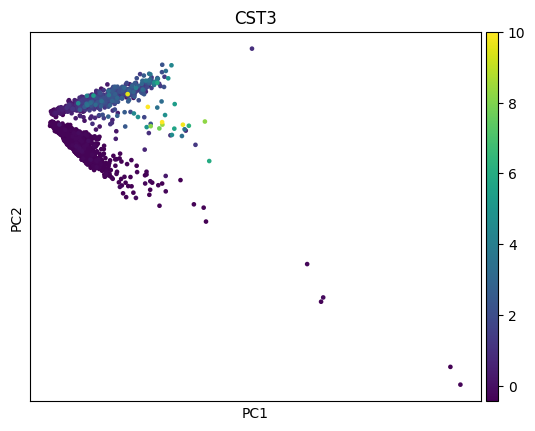

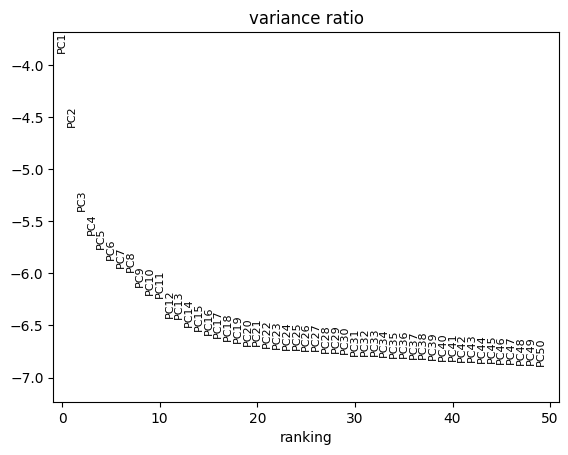

In [18]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)
sc.pl.pca(adata, color='CST3', save='_pca.png')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50, save='_elbow.png')  

Here, I make a PCA from the 50 principal components (90% of the variance explained)
also, I do an elbow plot, to see each principal component individually 

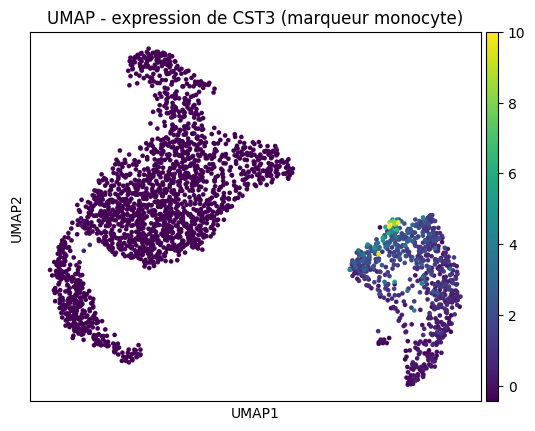

In [19]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50) # we take 10 neighbours for each cell. PC = 50
sc.tl.umap(adata) # compute the umap values 

sc.pl.umap(adata, color='CST3',
    title='UMAP - expression de CST3 (marqueur monocyte)',
    save='_umap_cst3.png'
)

clusters here indicate different types of cells 
branches between the cluster could maybe indicate a state of differentiation (like monocytes -> macrophages)
(to review)

with PCs equal to 20 or even 5 : the shapes and clusters change 

         Falling back to preprocessing with `sc.pp.pca` and default params.


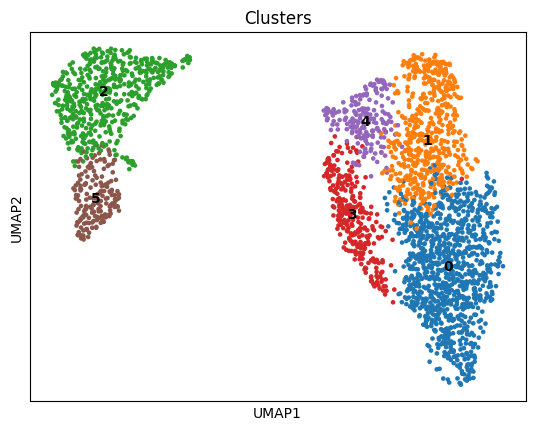

In [24]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5, key_added='leiden')
sc.pl.umap(adata, color='leiden', legend_loc='on data', title='Clusters')

Leider clustering, to visualize the different cellular types 
(on the interpretation : )

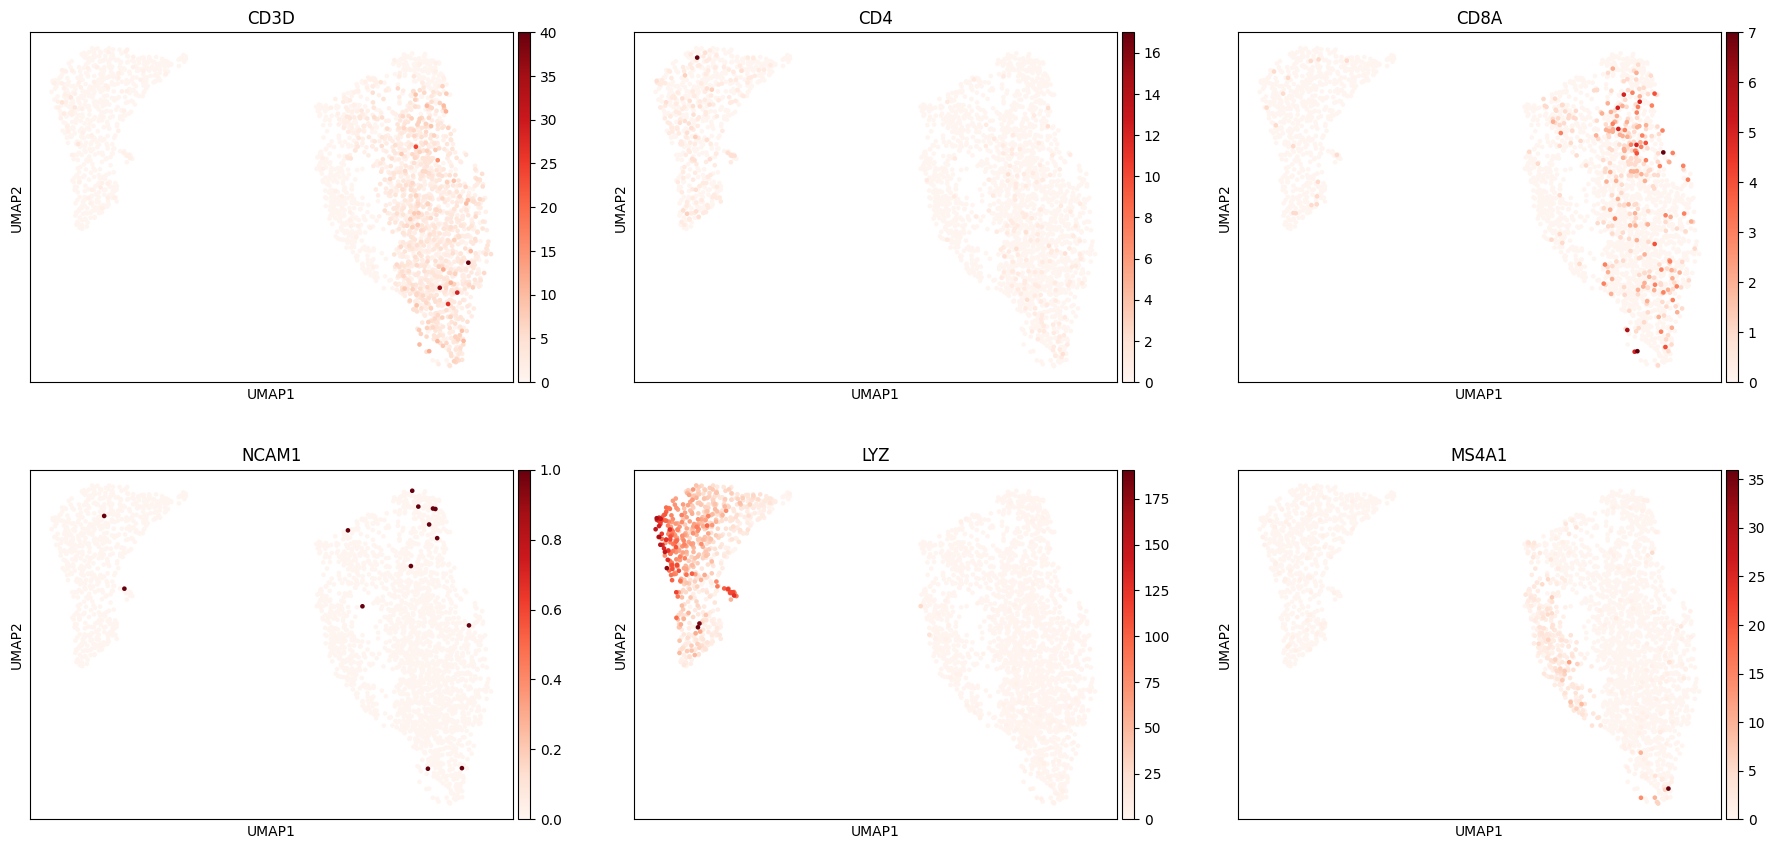

In [26]:
marker_genes = ['CD3D', 'CD4', 'CD8A', 'NCAM1', 'LYZ', 'MS4A1']
sc.pl.umap(adata, color=marker_genes, use_raw=False, ncols=3, color_map='Reds')


We can see here the T-cells (on the right, all the T-cells + NK cells with CD3D, and specifically the CD4+ with the marker CD4 and CD8+ with CD8A)

also, the NK cells (marker : NCAM1)

and the monocytes (marker : LYZ)

and the B cells (marker : Ms4A1)

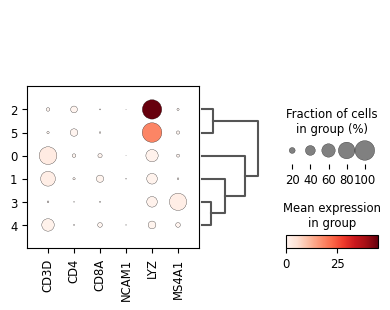

In [27]:
sc.pl.dotplot(adata, var_names=marker_genes, groupby='leiden', dendrogram=True)

I add a dotplot, in order to see easily which cell population is in each leiden group 

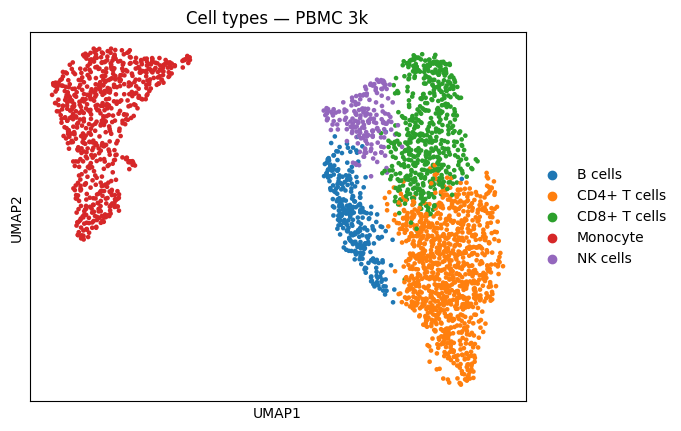

In [28]:
cluster_to_celltype = {
    '0': 'CD4+ T cells',    # T cell, but which ? less CD+8
    '1': 'CD8+ T cells',    # T cell, but which ? more CD+8
    '2': 'Monocyte',        # clear
    '3': 'B cells',         # clear 
    '4': 'NK cells',        # NK cell (last one with CD3D but no CD4 or CD8)
    '5': 'Monocyte'         # clear 
}
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype)

sc.pl.umap(adata, color='cell_type', legend_loc='right margin',
           title='Cell types — PBMC 3k')

I try to annotate the data with the correct types
some are easy, some are not
(at this point, I didn't clean the data, maybe it's the reason why it's not so clear)

# now, let's try to determinate the T cells exhaustion
to do so, we consider the 3 following exhaustion factors : PD-1, TIM-3 and LAG-3
(these are target in immunotherapy ! targeted by nivolumab (PD-1) or relatlimab (LAG-3), ...) 


marqueurs disponibles : ['PDCD1', 'HAVCR2', 'LAG3']


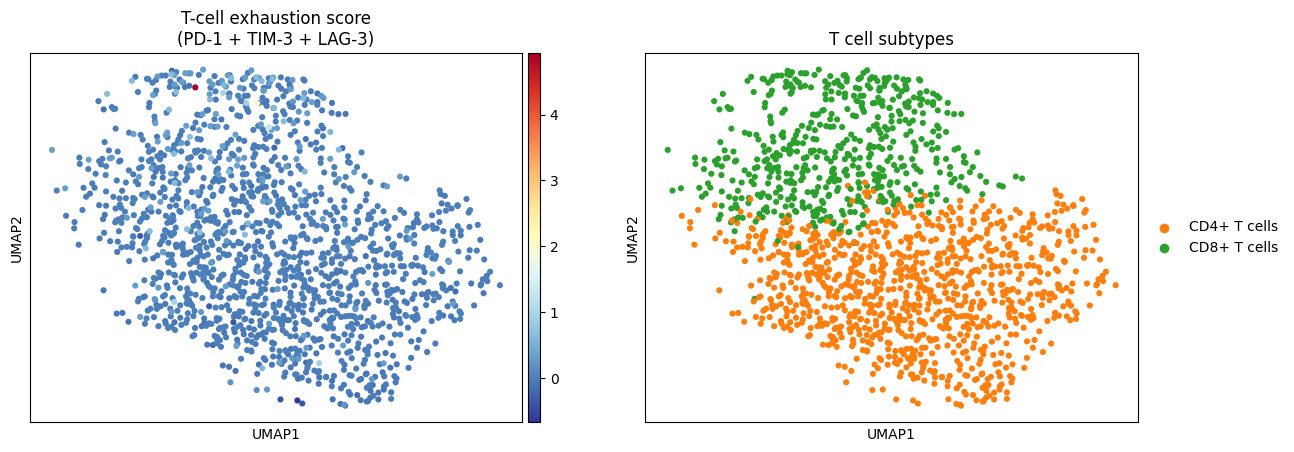

In [ ]:
t_mask = adata.obs['cell_type'].str.contains('T cells', na=False) # we only keep the T cells 
adata_t = adata[t_mask].copy()


exhaust_genes = ['PDCD1', 'HAVCR2', 'LAG3']
available = [g for g in exhaust_genes if g in adata_t.var_names]
print(f"marqueurs disponibles : {available}")                   # to be sure that the genes are indeed in the dataset

sc.tl.score_genes(adata_t, gene_list=available,
                  score_name='exhaustion_score')

sc.pl.umap(adata_t,
           color=['exhaustion_score', 'cell_type'],
           color_map='RdYlBu_r',
           ncols=2,
           title=['T-cell exhaustion score\n(PD-1 + TIM-3 + LAG-3)',
                  'T cell subtypes'])

We see that exhaustion score is zero on almost every cell.
This result is consistent with the nature of the donnor, who is healthy

We don't expect to see activation of exhaustion factors in T cells not activated 

# This analysis pipeline can be applied to tumor infiltrating lymphocyte (TIL) datasets, where exhaustion signatures are markers that predict response to checkpoint based immunotherapy